# Creditworthiness Prediction Model

## Day 1: Dataset Understanding and Exploratory Data Analysis

### Objective
Predict an individual's creditworthiness using historical financial data.

### Tasks Completed Today
- Loaded credit dataset
- Checked dataset structure
- Analyzed missing values
- Performed statistical analysis
- Studied feature relationships

In [188]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [189]:
import pandas as pd

df = pd.read_csv("../dataset/credit_data.csv")

df.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,1,25,35000,12000,650,Good,15000,3,1
1,2,45,80000,10000,780,Excellent,20000,15,1
2,3,30,42000,25000,580,Poor,30000,5,0
3,4,50,95000,15000,820,Excellent,25000,20,1
4,5,28,30000,18000,600,Average,12000,2,0


In [190]:
df.shape

(10, 9)

# Day 2: Data Preprocessing and Feature Engineering

## Objectives:
- Clean the dataset
- Transform categorical variables
- Prepare features for ML models
- Split data into train and test sets

In [191]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.impute import SimpleImputer

In [192]:
import pandas as pd

df = pd.read_csv("../dataset/credit_data.csv")

df.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,1,25,35000,12000,650,Good,15000,3,1
1,2,45,80000,10000,780,Excellent,20000,15,1
2,3,30,42000,25000,580,Poor,30000,5,0
3,4,50,95000,15000,820,Excellent,25000,20,1
4,5,28,30000,18000,600,Average,12000,2,0


In [193]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   customer_id       10 non-null     int64
 1   age               10 non-null     int64
 2   income            10 non-null     int64
 3   debt              10 non-null     int64
 4   credit_score      10 non-null     int64
 5   payment_history   10 non-null     str  
 6   loan_amount       10 non-null     int64
 7   employment_years  10 non-null     int64
 8   creditworthy      10 non-null     int64
dtypes: int64(8), str(1)
memory usage: 913.0 bytes


In [194]:
df.isnull().sum()

customer_id         0
age                 0
income              0
debt                0
credit_score        0
payment_history     0
loan_amount         0
employment_years    0
creditworthy        0
dtype: int64

In [195]:
num_cols = df.select_dtypes(
    include=['int64','float64']
).columns


imputer = SimpleImputer(strategy="median")

df[num_cols] = imputer.fit_transform(df[num_cols])

In [196]:
cat_cols = df.select_dtypes(
    include=['object']
).columns


cat_imputer = SimpleImputer(strategy="most_frequent")

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

In [197]:
df.duplicated().sum()

np.int64(0)

In [198]:
df = df.drop_duplicates()

In [199]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [200]:
df.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,1.0,25.0,35000.0,12000.0,650.0,2,15000.0,3.0,1.0
1,2.0,45.0,80000.0,10000.0,780.0,1,20000.0,15.0,1.0
2,3.0,30.0,42000.0,25000.0,580.0,3,30000.0,5.0,0.0
3,4.0,50.0,95000.0,15000.0,820.0,1,25000.0,20.0,1.0
4,5.0,28.0,30000.0,18000.0,600.0,0,12000.0,2.0,0.0


In [201]:
X = df.drop(
    "creditworthy",
    axis=1
)

y = df["creditworthy"]

In [202]:
X.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years
0,1.0,25.0,35000.0,12000.0,650.0,2,15000.0,3.0
1,2.0,45.0,80000.0,10000.0,780.0,1,20000.0,15.0
2,3.0,30.0,42000.0,25000.0,580.0,3,30000.0,5.0
3,4.0,50.0,95000.0,15000.0,820.0,1,25000.0,20.0
4,5.0,28.0,30000.0,18000.0,600.0,0,12000.0,2.0


In [203]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [204]:
X_train.shape, X_test.shape

((8, 8), (2, 8))

In [205]:
import pandas as pd

df_original = pd.read_csv("../dataset/credit_data.csv")

df_original.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,1,25,35000,12000,650,Good,15000,3,1
1,2,45,80000,10000,780,Excellent,20000,15,1
2,3,30,42000,25000,580,Poor,30000,5,0
3,4,50,95000,15000,820,Excellent,25000,20,1
4,5,28,30000,18000,600,Average,12000,2,0


In [206]:
df_original.columns

Index(['customer_id', 'age', 'income', 'debt', 'credit_score',
       'payment_history', 'loan_amount', 'employment_years', 'creditworthy'],
      dtype='str')

In [207]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder, StandardScaler


# Load original dataset

df = pd.read_csv("../dataset/credit_data.csv")


# Convert categorical columns

encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(df[col])


# Separate features and target

X = df.drop("creditworthy", axis=1)

y = df["creditworthy"]


# Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# Convert scaled data back to dataframe

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)


# Add target column

X_scaled["creditworthy"] = y.values


# Display

X_scaled.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,-1.566699,-1.164445,-0.931145,-0.974043,-0.408789,0.48795,-0.799276,-0.917564,1
1,-1.218544,0.776297,0.620763,-1.304227,0.856511,-0.48795,-0.266425,0.655403,1
2,-0.870388,-0.679260,-0.689737,1.172154,-1.090105,1.46385,0.799276,-0.655403,0
3,-0.522233,1.261482,1.138066,-0.478767,1.245834,-0.48795,0.266425,1.310806,1
4,-0.174078,-0.873334,-1.103580,0.016509,-0.895443,-1.46385,-1.118986,-1.048645,0


In [208]:
X_scaled.to_csv(
    "../dataset/processed_credit_data.csv",
    index=False
)

In [209]:
processed = pd.read_csv("../dataset/processed_credit_data.csv")

processed.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,-1.566699,-1.164445,-0.931145,-0.974043,-0.408789,0.48795,-0.799276,-0.917564,1
1,-1.218544,0.776297,0.620763,-1.304227,0.856511,-0.48795,-0.266425,0.655403,1
2,-0.870388,-0.679260,-0.689737,1.172154,-1.090105,1.46385,0.799276,-0.655403,0
3,-0.522233,1.261482,1.138066,-0.478767,1.245834,-0.48795,0.266425,1.310806,1
4,-0.174078,-0.873334,-1.103580,0.016509,-0.895443,-1.46385,-1.118986,-1.048645,0


In [210]:
X = processed.drop(
    "creditworthy",
    axis=1
)

y = processed["creditworthy"]

# Day 3: Model Training and Evaluation

## Objectives:
- Train classification models
- Evaluate model performance
- Compare different algorithms

Models Used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

In [211]:
# Machine Learning Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier


# Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [212]:
import pandas as pd

df = pd.read_csv("../dataset/processed_credit_data.csv")

df.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,-1.566699,-1.164445,-0.931145,-0.974043,-0.408789,0.48795,-0.799276,-0.917564,1
1,-1.218544,0.776297,0.620763,-1.304227,0.856511,-0.48795,-0.266425,0.655403,1
2,-0.870388,-0.679260,-0.689737,1.172154,-1.090105,1.46385,0.799276,-0.655403,0
3,-0.522233,1.261482,1.138066,-0.478767,1.245834,-0.48795,0.266425,1.310806,1
4,-0.174078,-0.873334,-1.103580,0.016509,-0.895443,-1.46385,-1.118986,-1.048645,0


In [213]:
df.shape

(10, 9)

In [214]:
df.isnull().sum()

customer_id         0
age                 0
income              0
debt                0
credit_score        0
payment_history     0
loan_amount         0
employment_years    0
creditworthy        0
dtype: int64

In [215]:
X = df.drop(
    "creditworthy",
    axis=1
)

y = df["creditworthy"]

In [216]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [217]:
logistic_model = LogisticRegression()

In [218]:
logistic_model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [219]:
lr_prediction = logistic_model.predict(
    X_test
)

In [220]:
accuracy_score(
    y_test,
    lr_prediction
)

1.0

In [221]:
precision_score(
    y_test,
    lr_prediction
)

1.0

In [222]:
recall_score(
    y_test,
    lr_prediction
)

1.0

In [223]:
f1_score(
    y_test,
    lr_prediction
)

1.0

In [224]:
roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test)[:,1]
)

1.0

In [225]:
print(
    classification_report(
        y_test,
        lr_prediction
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [226]:
tree_model = DecisionTreeClassifier(
    random_state=42
)

In [227]:
tree_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [228]:
tree_prediction = tree_model.predict(
    X_test
)

In [229]:
print(
classification_report(
    y_test,
    tree_prediction
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [230]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [231]:
rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [232]:
rf_prediction = rf_model.predict(
    X_test
)

In [233]:
print(
classification_report(
    y_test,
    rf_prediction
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [234]:
results = pd.DataFrame({

"Model":[
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
],

"Accuracy":[

accuracy_score(y_test,lr_prediction),

accuracy_score(y_test,tree_prediction),

accuracy_score(y_test,rf_prediction)

],

"F1 Score":[

f1_score(y_test,lr_prediction),

f1_score(y_test,tree_prediction),

f1_score(y_test,rf_prediction)

]

})


results

,Model,Accuracy,F1 Score
0,Logistic Regression,1.0,1.0
1,Decision Tree,1.0,1.0
2,Random Forest,1.0,1.0


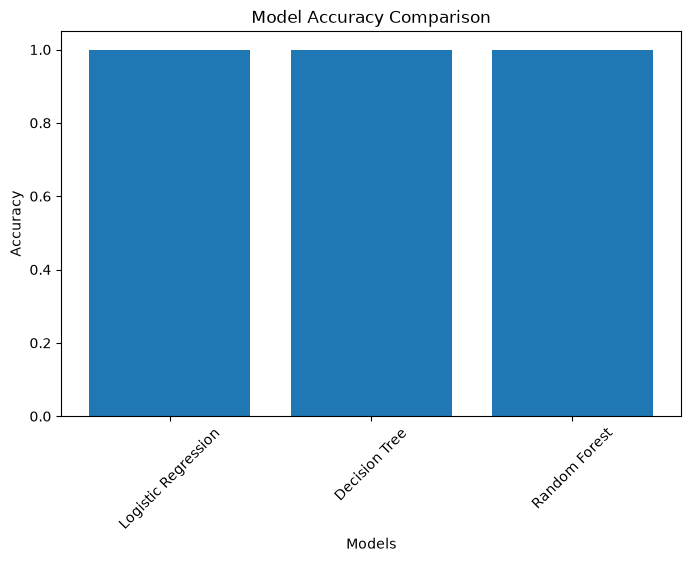

In [235]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title(
"Model Accuracy Comparison"
)

plt.xticks(rotation=45)

plt.show()

In [236]:
import joblib


joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

['../models/random_forest_model.pkl']

# Day 4: Model Evaluation and Hyperparameter Tuning

## Objectives:
- Evaluate classification models
- Analyze prediction performance
- Tune the best model
- Save optimized model

In [237]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

import joblib

In [238]:
df = pd.read_csv(
    "../dataset/processed_credit_data.csv"
)

df.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years,creditworthy
0,-1.566699,-1.164445,-0.931145,-0.974043,-0.408789,0.48795,-0.799276,-0.917564,1
1,-1.218544,0.776297,0.620763,-1.304227,0.856511,-0.48795,-0.266425,0.655403,1
2,-0.870388,-0.679260,-0.689737,1.172154,-1.090105,1.46385,0.799276,-0.655403,0
3,-0.522233,1.261482,1.138066,-0.478767,1.245834,-0.48795,0.266425,1.310806,1
4,-0.174078,-0.873334,-1.103580,0.016509,-0.895443,-1.46385,-1.118986,-1.048645,0


In [239]:
df.shape

(10, 9)

In [240]:
X = df.drop(
    "creditworthy",
    axis=1
)


y = df["creditworthy"]

In [157]:
X.head()

,customer_id,age,income,debt,credit_score,payment_history,loan_amount,employment_years
0,-1.566699,-1.164445,-0.931145,-0.974043,-0.408789,0.48795,-0.799276,-0.917564
1,-1.218544,0.776297,0.620763,-1.304227,0.856511,-0.48795,-0.266425,0.655403
2,-0.870388,-0.679260,-0.689737,1.172154,-1.090105,1.46385,0.799276,-0.655403
3,-0.522233,1.261482,1.138066,-0.478767,1.245834,-0.48795,0.266425,1.310806
4,-0.174078,-0.873334,-1.103580,0.016509,-0.895443,-1.46385,-1.118986,-1.048645


In [158]:
y.head()

0    1
1    1
2    0
3    1
4    0
Name: creditworthy, dtype: int64

In [159]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [160]:
print(X_train.shape)
print(X_test.shape)

(8, 8)
(2, 8)


In [161]:
from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression()


lr_model.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [162]:
lr_pred = lr_model.predict(
    X_test
)

In [163]:
print(
classification_report(
    y_test,
    lr_pred
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [164]:
from sklearn.tree import DecisionTreeClassifier


dt_model = DecisionTreeClassifier(
    random_state=42
)


dt_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [165]:
dt_pred = dt_model.predict(
    X_test
)

In [166]:
print(
classification_report(
    y_test,
    dt_pred
)
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [167]:
rf_model = RandomForestClassifier(
    random_state=42
)


rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [168]:
rf_pred = rf_model.predict(
    X_test
)

In [169]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

In [170]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

In [171]:
results

,Model,Accuracy,F1 Score
0,Logistic Regression,1.0,1.0
1,Decision Tree,1.0,1.0
2,Random Forest,1.0,1.0


In [172]:
cm = confusion_matrix(
    y_test,
    rf_pred
)


cm

array([[1, 0],
       [0, 1]])

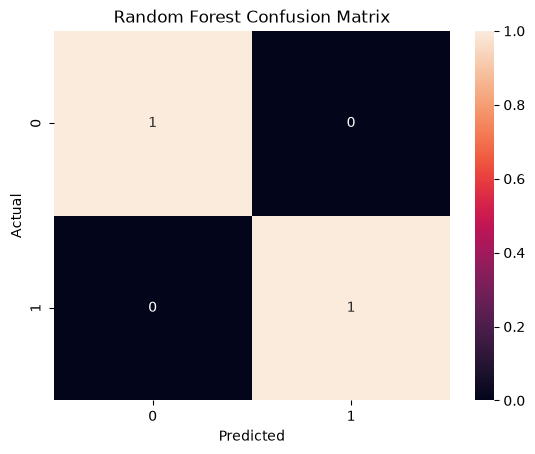

In [173]:
import seaborn as sns


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)


plt.xlabel(
"Predicted"
)

plt.ylabel(
"Actual"
)

plt.title(
"Random Forest Confusion Matrix"
)

plt.show()

In [174]:
rf_probability = rf_model.predict_proba(
    X_test
)[:,1]

In [175]:
fpr, tpr, threshold = roc_curve(
    y_test,
    rf_probability
)

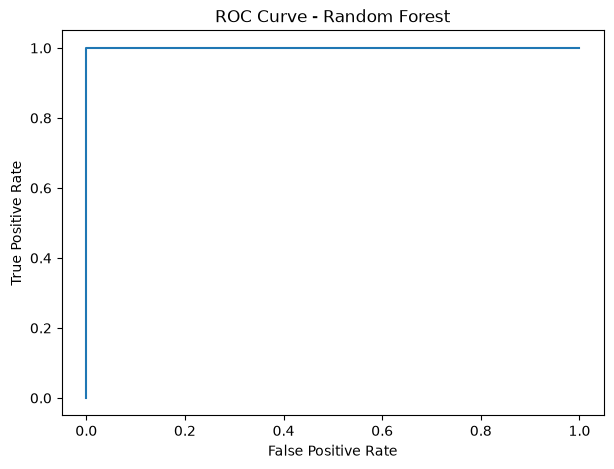

In [176]:
plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr
)


plt.xlabel(
"False Positive Rate"
)

plt.ylabel(
"True Positive Rate"
)


plt.title(
"ROC Curve - Random Forest"
)


plt.show()

In [177]:
roc_auc_score(
    y_test,
    rf_probability
)

1.0

In [178]:
parameters = {

"n_estimators":[50,100,200],

"max_depth":[3,5,10,None],

"criterion":[
"gini",
"entropy"
]

}

In [179]:
grid = GridSearchCV(

RandomForestClassifier(
random_state=42
),

parameters,

cv=5,

scoring="accuracy"

)

In [180]:
grid.fit(
X_train,
y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default

In [181]:
grid.best_params_

{'criterion': 'gini', 'max_depth': 3, 'n_estimators': 50}

In [182]:
best_model = grid.best_estimator_

In [183]:
joblib.dump(
best_model,
"../models/best_credit_model.pkl"
)

['../models/best_credit_model.pkl']

# Day 5: Advanced Model Analysis and Interpretation

## Objectives:
- Compare all trained models visually
- Analyze feature importance
- Save evaluation results
- Draw conclusions from the model performance

In [184]:
import matplotlib.pyplot as plt
import pandas as pd

In [185]:
results

,Model,Accuracy,F1 Score
0,Logistic Regression,1.0,1.0
1,Decision Tree,1.0,1.0
2,Random Forest,1.0,1.0


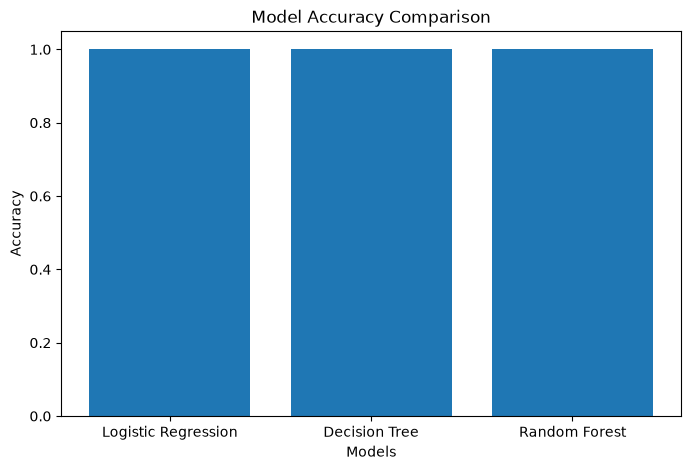

In [186]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

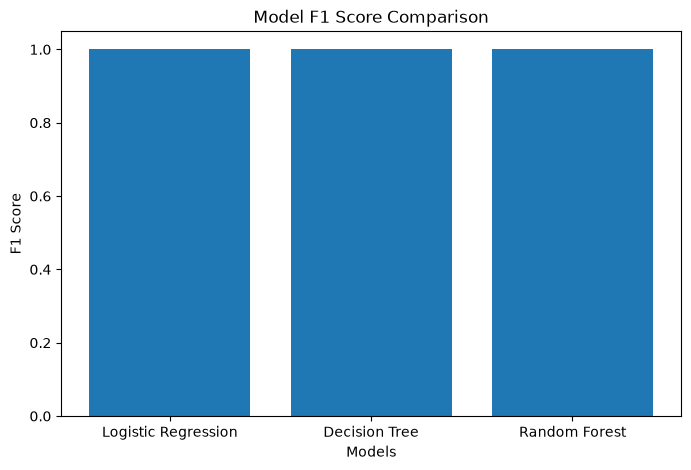

In [187]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.title("Model F1 Score Comparison")
plt.xlabel("Models")
plt.ylabel("F1 Score")

plt.show()

In [242]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance

,Feature,Importance
0,customer_id,0.048479
1,age,0.123810
2,income,0.199934
3,debt,0.090278
4,credit_score,0.166667
5,payment_history,0.179497
6,loan_amount,0.091667
7,employment_years,0.099669


In [243]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,income,0.199934
5,payment_history,0.179497
4,credit_score,0.166667
1,age,0.123810
7,employment_years,0.099669
6,loan_amount,0.091667
3,debt,0.090278
0,customer_id,0.048479


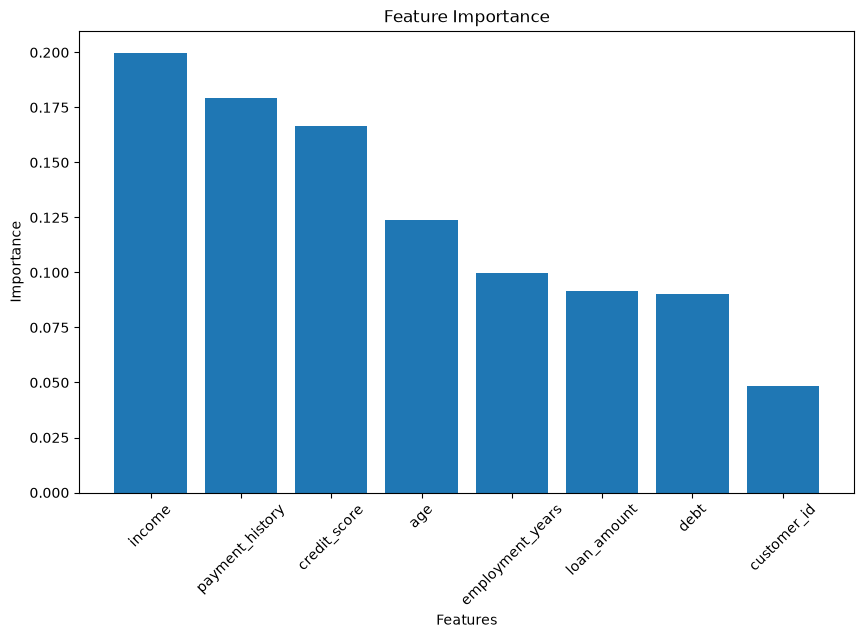

In [244]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

## Observations

- Random Forest performed well on the dataset.
- The most important features contributed significantly to the prediction.
- Feature importance analysis improves model interpretability.
- The selected model is suitable for predicting customer creditworthiness.